In [8]:
import pandas as pd
import numpy as np
import math
import warnings

def addColumns(data):
    #Add Responders vs Non Responder:
    # Responders: CR/PR, Non responder: PD
    responderCrit = data['BR'].isin(['CR','PR'])
    progressorCrit = data['BR'].isin(['PD'])

    
    data["PD_Responders"] = "SD/MR"
    responders = data[responderCrit].index
    progressors = data[progressorCrit].index
    nonresponders = data[~responderCrit].index
    nonprogressors = data[~progressorCrit].index
    
    data.loc[responders,"PD_Responders"] = 'Responder'
    data.loc[progressors,"PD_Responders"] = 'Progressor'

    #Add log neoantigen columns:
    neoantigen_cols = ["nonsyn_muts", "clonal_muts","subclonal_muts","total_neoantigens"]
    for col in neoantigen_cols:
        log_col = f"log_{col}"
        log_values = []
        for x in data[col]:
            if x < 0:
                warnings.warn(
                    f"There is abnormal value in the {col} column.",
                    DeprecationWarning,
                )
                log_values.append(math.log((0+1e-9), 10))
            else:
                log_values.append(math.log((x+1e-9), 10))
        data[log_col] = log_values
    return data
                
seed = 42
syn_datas = ["original_data",f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",f"synthpop_{seed}",f"tvae_{seed}"]
dataset_dict = {}
for syn_data in syn_datas:
    print(f"-----{syn_data}-----")
    df = pd.read_csv(f"Data/{syn_data}.csv",index_col = 0)
    processed_df = addColumns(df)
    dataset_dict[syn_data] = processed_df

-----original_data-----
-----avatarsk10_42-----
-----ctgan_42-----


/tmp/ipykernel_1464618/3139966997.py:29: DeprecationWarning: There is abnormal value in the nonsyn_muts column.
  warnings.warn(
/tmp/ipykernel_1464618/3139966997.py:29: DeprecationWarning: There is abnormal value in the clonal_muts column.
  warnings.warn(
/tmp/ipykernel_1464618/3139966997.py:29: DeprecationWarning: There is abnormal value in the subclonal_muts column.
  warnings.warn(
/tmp/ipykernel_1464618/3139966997.py:29: DeprecationWarning: There is abnormal value in the total_neoantigens column.
  warnings.warn(


-----gaussiancopula_42-----
-----synthpop_42-----
-----tvae_42-----


/tmp/ipykernel_1464618/3139966997.py:29: DeprecationWarning: There is abnormal value in the nonsyn_muts column.
  warnings.warn(
/tmp/ipykernel_1464618/3139966997.py:29: DeprecationWarning: There is abnormal value in the clonal_muts column.
  warnings.warn(
/tmp/ipykernel_1464618/3139966997.py:29: DeprecationWarning: There is abnormal value in the subclonal_muts column.
  warnings.warn(
/tmp/ipykernel_1464618/3139966997.py:29: DeprecationWarning: There is abnormal value in the total_neoantigens column.
  warnings.warn(


In [2]:
# Fig 2h - hierarchical clustering of genomic and transcriptomic features
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns
import matplotlib.pyplot as plt
fullDF = dataset_dict["original_data"]
comparators = [
            'log_nonsyn_muts',
             'log_clonal_muts',
              'heterogeneity',
              'purity',
                'ploidy',
             'CNA_prop',
               'log_total_neoantigens',
    'HLA-DMA', 'HLA-DMB', 'HLA-DOA', 'HLA-DOB', 'HLA-DPA1', 'HLA-DPB1', 
        'HLA-DQA1', 'HLA-DQA2', 'HLA-DQB1', 'HLA-DQB2', 'HLA-DRA', 'HLA-DRB1', 
        'HLA-DRB5',
            'HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'TAP1', 'TAP2', 'B2M',
            'MHCI_Amp',
            'TAP2_Amp',
               'Tx_Start_LDH',
                ]

def cluster_features(data, method = "ward"):
    corrmat = data.corr()
    # 2. Replace NaN/infinite with 0 (or another value as needed)
    if corrmat.isnull().values.any() or np.isinf(corrmat.values).any():
        print("Warning: NaNs/Infs found in correlation matrix, filling with 0.")
        corrmat = corrmat.fillna(0)
        corrmat.replace([np.inf, -np.inf], 0, inplace=True)
    
    Z = linkage(corrmat, method=method)
    plt.ioff()

    dendrogram_output = dendrogram(
        Z, 
        leaf_rotation=90, 
        leaf_font_size=6
    )
    
    order = [int(s) for s in dendrogram_output['ivl']]
    plt.close()
    return Z, order, corrmat

In [4]:
def draw_clustermap(corrmatrix, order, feature_groups, color_map, figsize, filepath):
    # Defensive: ensure corrmatrix and order are correct
    if len(order) != len(corrmatrix.index):
        raise ValueError(f"Length of 'order' ({len(order)}) does not match corrmatrix shape ({corrmatrix.shape})")

    # Map order to actual feature names
    ordered_features = corrmatrix.index[order]
    # Build color annotations for each feature
    col_colors = []
    for feat in ordered_features:
        found = False
        for fg, members in feature_groups.items():
            if feat in members:
                col_colors.append(color_map.get(fg, color_map["Other"]))
                found = True
                break
        if not found:
            col_colors.append(color_map["Other"])

    # Defensive: subset/align corrmatrix to ordered_features
    corr_sub = corrmatrix.loc[ordered_features, ordered_features]

    cg = sns.clustermap(
        corr_sub,
        cmap="coolwarm",
        center=0,
        row_colors=col_colors,
        col_colors=col_colors,
        linewidths=0,   
        figsize=figsize,
    )


    # Improve label rotation / font size
    plt.setp(cg.ax_heatmap.yaxis.get_majorticklabels(), rotation=0, fontsize=10)
    plt.setp(cg.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, fontsize=10)
    # plt.tight_layout()
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.show()
    return cg

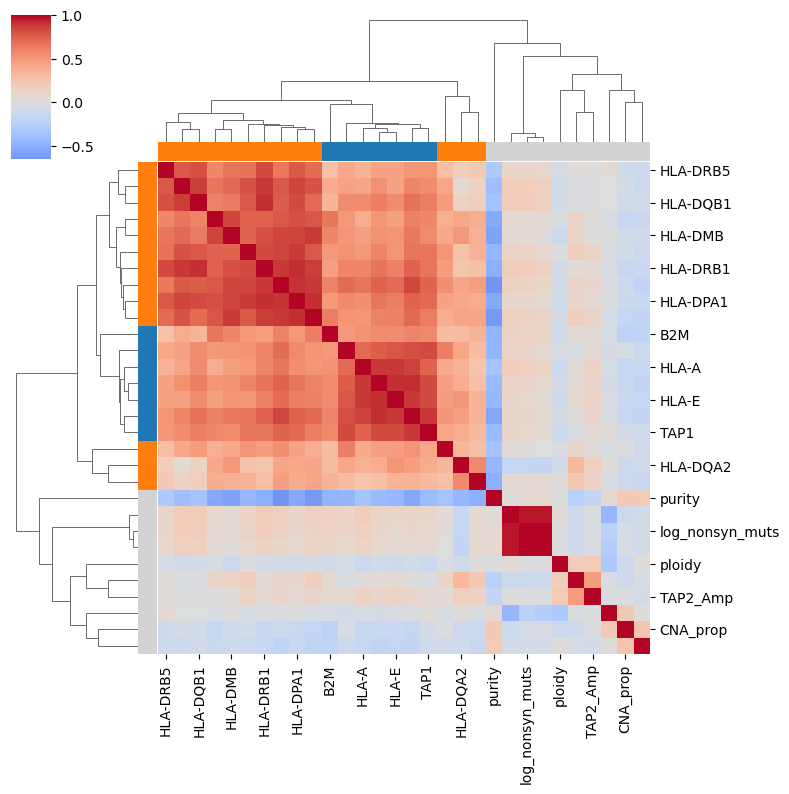

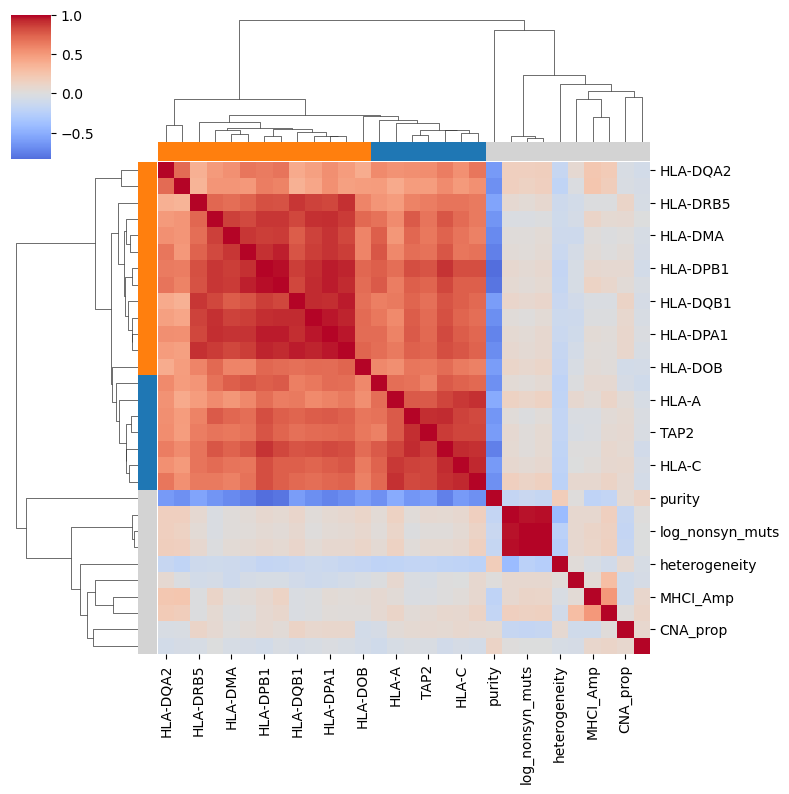

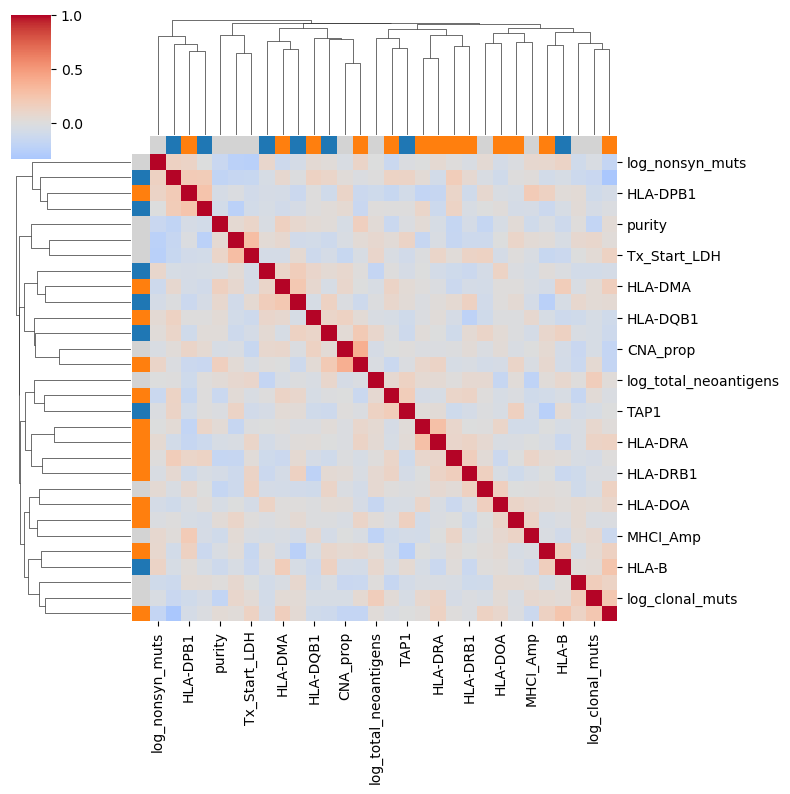

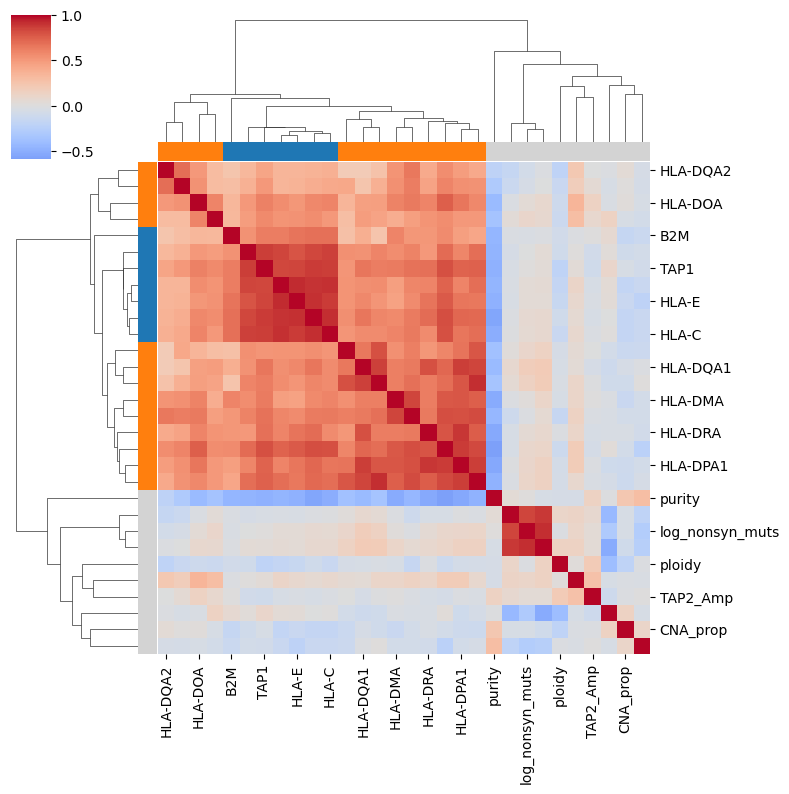

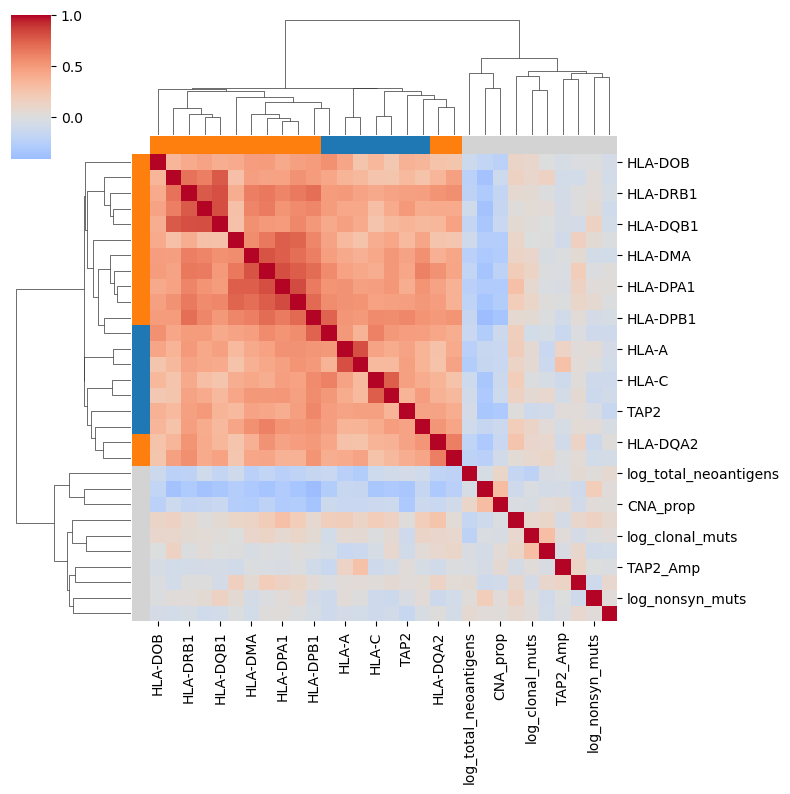

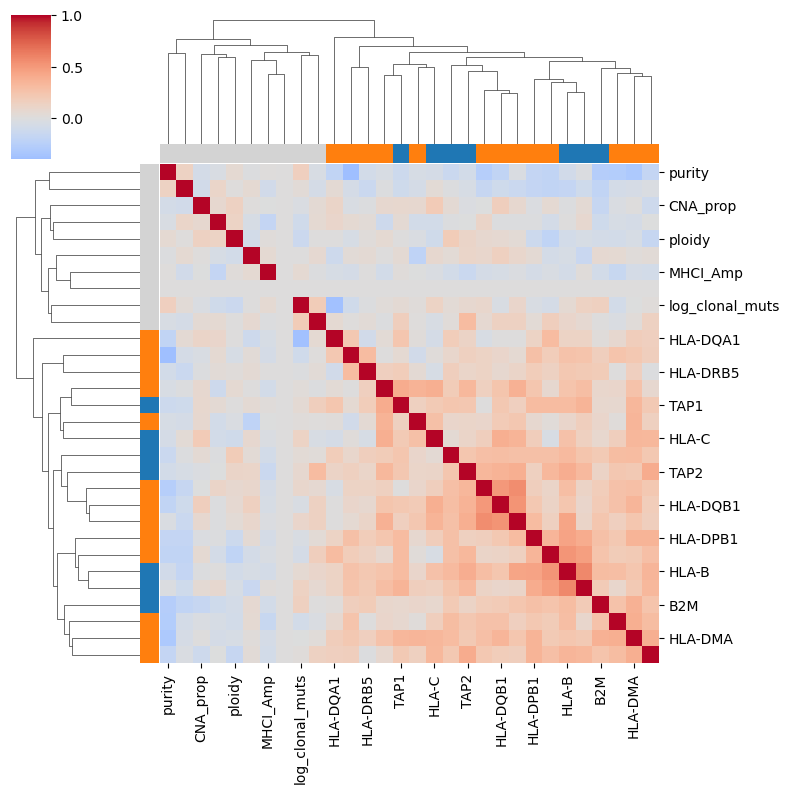

In [6]:
figsize = (8, 8)
feature_groups = {"MHC1": ['HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'HLA-F', 'TAP1', 'TAP2', 'B2M'],
                 "MHC2": [
    'HLA-DMA', 'HLA-DMB', 'HLA-DOA', 'HLA-DOB', 'HLA-DPA1', 'HLA-DPB1',
    'HLA-DQA1', 'HLA-DQA2', 'HLA-DQB1', 'HLA-DQB2', 'HLA-DRA', 'HLA-DRB1',
    'HLA-DRB5'
]}

# colors for the groups (choose your palette)
color_map = {
    "MHC1": "#1f77b4",    # blue
    "MHC2": "#ff7f0e",    # orange
    "Other": "#d3d3d3"    # light gray
}
for tool, data in dataset_dict.items():
    comparator_df = data[comparators]
    Z,  order, corrmat = cluster_features(comparator_df, "ward")
    filepath = f"PairwiseClinical/PairwiseClinical_{seed}/{tool}.pdf"
    cg = draw_clustermap(corrmat, order, feature_groups, color_map, figsize = figsize, filepath = filepath)

In [12]:
from scipy.stats import ranksums
from statsmodels.sandbox.stats.multicomp import multipletests
from tqdm import tqdm
from joblib import Parallel, delayed
import numpy as np
import pandas as pd

def degs_analysis(gene_expressions, metadata, phenotypes, id_col, n_jobs=-1, verbose=0):

    ph_column, ph_values = next(iter(phenotypes.items()))
    if len(ph_values) != 2:
        raise ValueError(f"Phenotype values list must contain exactly two values, got: {ph_values}")

    phenotype_A, phenotype_B = ph_values

    phenotypeA_samples = metadata[metadata[ph_column] == phenotype_A][id_col].values.tolist()
    phenotypeB_samples = metadata[metadata[ph_column] == phenotype_B][id_col].values.tolist()

    if len(phenotypeA_samples) == 0 or len(phenotypeB_samples) == 0:
        raise ValueError("One of the phenotype groups has no samples.")

    phenotypeA_DF = gene_expressions.loc[phenotypeA_samples, :]
    phenotypeB_DF = gene_expressions.loc[phenotypeB_samples, :]

    genelist = gene_expressions.columns.tolist()

    def process_gene(gene):
        phenotypeA_exp = phenotypeA_DF[gene].values
        phenotypeB_exp = phenotypeB_DF[gene].values

        # Edge case flags
        status = []

        # Handle arrays full of NaN or empty
        if np.all(np.isnan(phenotypeA_exp)) or len(phenotypeA_exp) == 0:
            status.append(f"A_all_nan_or_empty")
        if np.all(np.isnan(phenotypeB_exp)) or len(phenotypeB_exp) == 0:
            status.append(f"B_all_nan_or_empty")

        # Remove NaNs (rank-sum test can't handle)
        cleaned_A_exp = phenotypeA_exp[~np.isnan(phenotypeA_exp)]
        cleaned_B_exp = phenotypeB_exp[~np.isnan(phenotypeB_exp)]

        if len(cleaned_A_exp) == 0 or len(cleaned_B_exp) == 0:
            pvalue = np.nan
            status.append("No_data")
        else:
            # Check if both are constant or identical
            if np.all(cleaned_A_exp == cleaned_A_exp[0]) and np.all(cleaned_B_exp == cleaned_B_exp[0]) and cleaned_A_exp[0] == cleaned_B_exp[0]:
                pvalue = 1.0
                status.append("Identical")
            else:
                try:
                    _, pvalue = ranksums(cleaned_A_exp, cleaned_B_exp, alternative='two-sided')
                    if np.isnan(pvalue):
                        status.append("p_nan")
                except Exception as e:
                    pvalue = np.nan
                    status.append(f"ranksums_error:{str(e)}")

        mean_A = np.nanmean(cleaned_A_exp) if len(cleaned_A_exp) else np.nan
        mean_B = np.nanmean(cleaned_B_exp) if len(cleaned_B_exp) else np.nan

        # Log2FC with safe handling (including zeros, NaN, infinite)
        if np.isnan(mean_A) or np.isnan(mean_B):
            log2fc = np.nan
            status.append("FC_nan")
        elif mean_A == mean_B == 0:
            log2fc = 0.0
            status.append("FC_both_zero")
        elif mean_B == 0:
            log2fc = np.inf if mean_A > 0 else np.nan
            status.append("FC_div_zero")
        elif mean_A == 0:
            log2fc = -np.inf if mean_B > 0 else np.nan
            status.append("FC_div_zero")
        else:
            log2fc = np.log2(mean_A / mean_B)

        if not status:
            status = ["ok"]
        return pvalue, log2fc, ";".join(status)

    # Parallel processing
    results = Parallel(n_jobs=n_jobs, verbose=verbose)(
        delayed(process_gene)(gene) for gene in tqdm(genelist, desc="DE analysis")
    )
    pvalues, log2FCs, statusflags = zip(*results)

    
    results_df = pd.DataFrame(
        {
            "Gene": genelist,
            "P_value": pvalues,
            "Log2FC": log2FCs,
            "Status": statusflags,
        }
    )
    
    # Multiple testing correction (protect against all-NaN p-values)
    pvalues = np.asarray(results_df["P_value"].values)
    valid_p_mask = ~pd.isnull(pvalues)
    valid_pvalues = np.array(pvalues)[valid_p_mask]
    qvalues = np.full_like(pvalues, np.nan, dtype=np.double)
    if valid_pvalues.size > 0:
        _, qvals_valid, _, _ = multipletests(valid_pvalues, method='fdr_bh')
        qvalues = np.array(qvalues)
        qvalues[valid_p_mask] = qvals_valid
    
    results_df['Q_value'] = qvalues
    # Rank_Score is only computed for valid Log2FC and Q_value
    results_df["Rank_Score"] = np.where(
        pd.isnull(results_df["Log2FC"]) | pd.isnull(results_df["Q_value"]),
        np.nan,
        (results_df["Log2FC"]) * (-np.log10(results_df["Q_value"]))
    )
    return results_df

In [13]:
degs_results = {}
for name, data in dataset_dict.items():
    print(f"----DEGs Analysis {name} ----")
    genelist = data.columns.tolist()[54:-5]
    metadata = pd.DataFrame(
        {"Patient": data.index,
        "PD_Responders": data["PD_Responders"].values.tolist()}
    )
    gene_expressions = data[genelist]
    id_col = "Patient"
    phenotypes = {"PD_Responders": ["Responder","Progressor"]}
    degs_df = degs_analysis(gene_expressions, metadata, phenotypes, id_col, n_jobs=-1, verbose=0)
    degs_df.to_csv(f"DEGs/DEGs_{name}_{seed}.csv", index = False)
    degs_results[name] = degs_df

----DEGs Analysis original_data ----


DE analysis: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18760/18760 [00:33<00:00, 551.93it/s]


----DEGs Analysis avatarsk10_42 ----


DE analysis: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18760/18760 [00:02<00:00, 8178.38it/s]


----DEGs Analysis ctgan_42 ----


...

DE analysis:   1%|██▊                                                                                                                                                                                                                      | 240/18760 [00:00<00:25, 739.44it/s]/tmp/ipykernel_2831549/865390385.py:78: RuntimeWarning: invalid value encountered in log2
/tmp/ipykernel_2831549/865390385.py:78: RuntimeWarning: invalid value encountered in log2
/tmp/ipykernel_2831549/865390385.py:78: RuntimeWarning: invalid value encountered in log2
DE analysis:   5%|██████████▌                                                                                                                                                                                                             | 912/18760 [00:00<00:11, 1597.87it/s]/tmp/ipykernel_2831549/865390385.py:78: RuntimeWarning: invalid value encountered in log2
/tmp/ipykernel_2831549/865390385.py:78: RuntimeWarning: invalid value encountered in log2
/tmp/i

----DEGs Analysis synthpop_42 ----


DE analysis: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18760/18760 [00:02<00:00, 7641.05it/s]


----DEGs Analysis tvae_42 ----


DE analysis:   2%|████▍                                                                                                                                                                                                                    | 384/18760 [00:00<00:31, 589.42it/s]/tmp/ipykernel_2831549/865390385.py:78: RuntimeWarning: invalid value encountered in log2
/tmp/ipykernel_2831549/865390385.py:78: RuntimeWarning: invalid value encountered in log2
DE analysis:   4%|███████▋                                                                                                                                                                                                                | 672/18760 [00:00<00:16, 1072.05it/s]/tmp/ipykernel_2831549/865390385.py:78: RuntimeWarning: invalid value encountered in log2
/tmp/ipykernel_2831549/865390385.py:78: RuntimeWarning: invalid value encountered in log2
DE analysis:   9%|██████████████████▋                                                           

In [20]:
from collections import Iterable
from typing import Dict, Optional, Tuple, Any, List

def _to_set(pathways: Iterable[Any], case_sensitive: bool = False) -> set:
    if pathways is None:
        return set()
    if not case_sensitive:
        return {str(x).strip().lower() for x in pathways if pd.notna(x)}
    else:
        return {str(x).strip() for x in pathways if pd.notna(x)}


def compute_jaccard_indices(
    original_pathways: Iterable[Any],
    synth_pathways_dict: Dict[str, Iterable[Any]],
    case_sensitive: bool = False,
) -> pd.DataFrame:
    """
    The Jaccard index is defined as:
        J(A, B) = |A ∩ B| / |A ∪ B|
    """
    if not isinstance(synth_pathways_dict, dict):
        raise ValueError("synth_pathways_dict must be a dict mapping dataset name -> iterable of pathways")

    A = _to_set(original_pathways, case_sensitive=case_sensitive)
    rows = []
    for ds_name, synth_paths in synth_pathways_dict.items():
        B = _to_set(synth_paths, case_sensitive=case_sensitive)
        inter = A.intersection(B)
        union = A.union(B)
        inter_size = len(inter)
        union_size = len(union)

        if union_size == 0:
            # both sets empty -> identical
            j = 1.0
        else:
            j = inter_size / union_size

        rows.append(
            {
                "Dataset": ds_name,
                "Original_count": len(A),
                "Synthetic_count": len(B),
                "Intersection": inter_size,
                "Union": union_size,
                "Jaccard": j,
            }
        )

    df = pd.DataFrame(rows, columns=["Dataset", "Original_count", "Synthetic_count", "Intersection", "Union", "Jaccard"])
    return df


def extract_significant_pathways(
    df: pd.DataFrame,
    term_col: str = "Term",
    adj_p_col: str = "P_value",
    threshold: float = 0.05,
) -> List[str]:
    if df is None or df.empty:
        return []
    if term_col not in df.columns or adj_p_col not in df.columns:
        return []
    sub = df[df[adj_p_col].astype(float) < float(threshold)].copy()
    # drop NA/empty terms and return list
    sub = sub[sub[term_col].notna()]
    return [str(x).strip() for x in sub[term_col].tolist()]

In [28]:
orig_genes = extract_significant_pathways(degs_results["original_data"], term_col="Gene", adj_p_col="P_value", threshold=0.05)
synth_genes_dict = {k: extract_significant_pathways(v, term_col="Gene", adj_p_col="P_value", threshold=0.05)
                     for k, v in degs_results.items() if k != "original_data"}
jaccard_df = compute_jaccard_indices(orig_genes, synth_genes_dict)
jaccard_df.to_csv(f"DEGs/JaccardIndex_{seed}.csv", index = False)
jaccard_df

,Dataset,Original_count,Synthetic_count,Intersection,Union,Jaccard
0,avatarsk10_42,1415,2763,370,3808,0.097164
1,ctgan_42,1415,1224,81,2558,0.031665
2,gaussiancopula_42,1415,1956,506,2865,0.176614
3,synthpop_42,1415,709,48,2076,0.023121
4,tvae_42,1415,3061,256,4220,0.060664


In [36]:
from scipy.stats import spearmanr
DEGs_list = []
for name, df in degs_results.items():
    df["Dataset"] = name
    DEGs_list.append(df)
DEGs_df = pd.concat(DEGs_list, axis = 0)
pivot_df = DEGs_df.pivot_table(
    index="Gene",
    columns="Dataset",
    values="Rank_Score"
)


origin_values = pivot_df["original_data"]

results = []

for dataset in pivot_df.columns:
    if dataset == "original_data":
        continue  # skip comparison with itself
    
    x = origin_values
    y = pivot_df[dataset]

    # Drop rows where either side is NaN
    valid = ~(x.isna() | y.isna())
    rho, pval = spearmanr(x[valid], y[valid])

    results.append({
        "Dataset": dataset,
        "Spearman_rho": rho,
        "p_value": pval,
        "n_terms_used": valid.sum()
    })

# Convert results to DataFrame
spearman_df = pd.DataFrame(results)
spearman_df.to_csv(f"DEGs/Spearman_df{seed}.csv", index = False)
spearman_df

,Dataset,Spearman_rho,p_value,n_terms_used
0,avatarsk10_42,0.369054,0.000000e+00,18760
1,ctgan_42,-0.003830,6.066722e-01,18072
2,gaussiancopula_42,0.463388,0.000000e+00,18551
3,synthpop_42,0.064486,9.482882e-19,18760
4,tvae_42,0.252170,6.547212e-269,18685


In [37]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import seaborn as sns
def plot_jaccard_vs_spearman(
    jaccard_df: pd.DataFrame,
    spearman_df: pd.DataFrame,
    dataset_col: str = "Dataset",
    jaccard_col: str = "Jaccard",
    spearman_col: str = "Spearman_rho",
    size_col: Optional[str] = "Synthetic_count",
    annotate: bool = True,
    figsize: Tuple[float, float] = (8, 6),
    savepath: Optional[str] = None,
    title: Optional[str] = "Jaccard index vs Spearman rho",
) -> Tuple[plt.Figure, plt.Axes]:
    # Validate inputs
    if dataset_col not in jaccard_df.columns:
        raise ValueError(f"{dataset_col} not found in jaccard_df")
    if dataset_col not in spearman_df.columns:
        raise ValueError(f"{dataset_col} not found in spearman_df")
    if jaccard_col not in jaccard_df.columns:
        raise ValueError(f"{jaccard_col} not found in jaccard_df")
    if spearman_col not in spearman_df.columns:
        raise ValueError(f"{spearman_col} not found in spearman_df")

    # Merge on dataset
    df = pd.merge(
        spearman_df,
        jaccard_df,
        on=dataset_col,
        how="outer",
        suffixes=("_spearman", "_jaccard"),
    )

    # Prepare columns
    df = df.rename(columns={jaccard_col: "Jaccard", spearman_col: "Spearman_rho"})
    # If user requested size_col but it has different name in jaccard_df, try to keep as-is
    if size_col is not None and size_col not in df.columns:
        # fall back to n_terms_used or Synthetic_count if available
        if "n_terms_used" in df.columns:
            size_col = "n_terms_used"
        elif "Synthetic_count" in df.columns:
            size_col = "Synthetic_count"
        else:
            size_col = None

    # Drop rows that do not have both metrics (can't plot)
    plot_df = df.loc[df["Jaccard"].notna() & df["Spearman_rho"].notna()].copy()

    # If no rows to plot, create empty figure with message
    if plot_df.shape[0] == 0:
        fig, ax = plt.subplots(figsize=figsize)
        ax.text(0.5, 0.5, "No datasets with both Jaccard and Spearman available", ha="center", va="center")
        ax.axis("off")
        if savepath:
            fig.savefig(savepath, dpi=300, bbox_inches="tight")
        return fig, ax

    # # Compute Spearman correlation between Jaccard and Spearman_rho (on available rows)
    # rho, pval = spearmanr(plot_df["Jaccard"], plot_df["Spearman_rho"], nan_policy="omit")

    # Determine point sizes
    if size_col is not None:
        # scale sizes to a reasonable range
        raw_sizes = plot_df[size_col].fillna(0).astype(float)
        # map zero -> small, others scaled
        min_size = 50
        max_size = 450
        if raw_sizes.max() == raw_sizes.min():
            sizes = np.full(len(raw_sizes), (min_size + max_size) / 2.0)
        else:
            sizes = min_size + (raw_sizes - raw_sizes.min()) / (raw_sizes.max() - raw_sizes.min()) * (max_size - min_size)
    else:
        sizes = 120

    # Create plot
    sns.set(style="whitegrid")
    fig, ax = plt.subplots(figsize=figsize)

    scatter = ax.scatter(
        x=plot_df["Jaccard"],
        y=plot_df["Spearman_rho"],
        s=sizes,
        c="tab:blue",
        edgecolor="k",
        alpha=0.85,
        linewidth=0.6,
        zorder=3,
    )


    # Annotate each point with dataset name if requested (with small offset)
    if annotate:
        for _, row in plot_df.iterrows():
            dx = 0.005 * (ax.get_xlim()[1] - ax.get_xlim()[0])  # small fraction of x-range
            dy = 0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0])  # small fraction of y-range
            ax.text(
                row["Jaccard"] + dx,
                row["Spearman_rho"] + dy,
                str(row[dataset_col]),
                fontsize=8,
                verticalalignment="bottom",
                horizontalalignment="left",
            )

    # Labels, title, legend, annotation for correlation
    ax.set_xlabel("Jaccard index", fontsize=11)
    ax.set_ylabel("Spearman rho", fontsize=11)
    ax.set_title(title, fontsize=12)



    # A grid and tight layout
    ax.grid(alpha=0.4, linestyle="--")
    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    return fig, ax

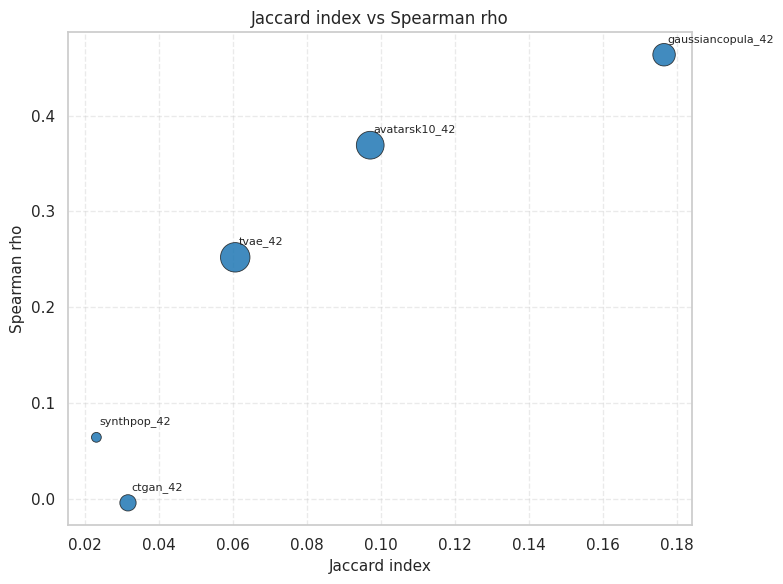

In [38]:
fig, ax = plot_jaccard_vs_spearman(jaccard_df, spearman_df, 
                                   size_col="Synthetic_count", annotate=True, savepath=f"DEGs/JaccardIndex_Spearman_{seed}.png")
plt.show()

In [44]:
from typing import List, Optional, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_volcano(
    df: pd.DataFrame,
    gene_col: str = 'Gene',
    log2fc_col: str = 'Log2FC',
    pval_col: str = 'P_value',
    pval_thresh: float = 0.05,
    mhc1: Optional[List[str]] = None,
    mhc2: Optional[List[str]] = None,
    annotate: bool = True,
    figsize: tuple = (8, 6),
    point_size: int = 20,
    alpha: float = 0.7,
    colors: Optional[Dict[str, str]] = None,
    title: str = "Volcano plot",
    savepath: Optional[str] = None,
    ax: Optional[plt.Axes] = None,
) -> plt.Figure:
    """
    Create a volcano plot.

    Parameters
    ----------
    df : pd.DataFrame
        Table containing gene names, log2 fold changes and p-values.
    gene_col : str
        Column name for gene identifiers.
    log2fc_col : str
        Column name for log2 fold change values.
    pval_col : str
        Column name for p-values.
    pval_thresh : float
        P-value threshold to draw dashed horizontal line at -log10(pval_thresh).
    mhc1 : list[str] or None
        Genes to highlight in color1.
    mhc2 : list[str] or None
        Genes to highlight in color2.
    annotate : bool
        Whether to label the highlighted genes on the plot.
    figsize : tuple
        Figure size.
    point_size : int
        Scatter point size.
    alpha : float
        Scatter alpha.
    colors : dict or None
        Optional mapping: {"background": "#cccccc", "mhc1": "blue", "mhc2": "orange"}.
    savepath : str or None
        If provided, saves the figure to this path.
    ax : matplotlib.axes.Axes or None
        If provided, draw on this axis and return its figure.

    Returns
    -------
    matplotlib.figure.Figure
        The figure object containing the volcano plot.
    """

    # Default colors
    default_colors = {
        "background": "#bdbdbd",
        "mhc1": "#1f77b4",   # blue
        "mhc2": "#ff7f0e",   # orange
        "edge": "k"
    }
    if colors is not None:
        default_colors.update(colors)

    if mhc1 is None:
        mhc1 = []
    if mhc2 is None:
        mhc2 = []

    # Validate required columns
    for col in (gene_col, log2fc_col, pval_col):
        if col not in df.columns:
            raise KeyError(f"Column '{col}' not found in DataFrame.")

    # Copy and coerce numeric columns safely
    plot_df = df.copy()
    plot_df[log2fc_col] = pd.to_numeric(plot_df[log2fc_col], errors='coerce')
    plot_df[pval_col] = pd.to_numeric(plot_df[pval_col], errors='coerce')

    # Drop rows missing both values
    plot_df = plot_df.dropna(subset=[log2fc_col, pval_col], how='any')

    # Handle zero p-values by flooring to tiny positive number
    tiny = 1e-300
    pvals = plot_df[pval_col].to_numpy(dtype=float)
    pvals_safe = np.where(np.isnan(pvals), np.nan, np.maximum(pvals, tiny))
    minus_log10_p = -np.log10(pvals_safe)

    # Prepare axis
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    sns.set_style("whitegrid")

    # Background points (all genes)
    ax.scatter(
        plot_df[log2fc_col],
        minus_log10_p,
        c=default_colors["background"],
        s=point_size,
        alpha=alpha,
        edgecolors='none',
        label='Other genes',
        zorder=2
    )

    # Helper to select genes present in the DataFrame
    gene_values = plot_df[gene_col].astype(str).tolist()
    gene_index_map = {g: i for i, g in enumerate(gene_values)}

    # Overlay mhc1
    mhc1_present = [g for g in mhc1 if g in gene_index_map]
    if mhc1_present:
        idxs = [gene_index_map[g] for g in mhc1_present]
        ax.scatter(
            plot_df.iloc[idxs][log2fc_col],
            minus_log10_p[idxs],
            c=default_colors["mhc1"],
            s=point_size * 1.6,
            alpha=1.0,
            edgecolors=default_colors["edge"],
            linewidths=0.6,
            label='MHC-I',
            zorder=3
        )

    # Overlay mhc2
    mhc2_present = [g for g in mhc2 if g in gene_index_map]
    if mhc2_present:
        idxs = [gene_index_map[g] for g in mhc2_present]
        ax.scatter(
            plot_df.iloc[idxs][log2fc_col],
            minus_log10_p[idxs],
            c=default_colors["mhc2"],
            s=point_size * 1.6,
            alpha=1.0,
            edgecolors=default_colors["edge"],
            linewidths=0.6,
            label='MHC-II',
            zorder=3
        )

    # Draw horizontal dashed line at p-value threshold
    y_thresh = -np.log10(max(pval_thresh, tiny))
    ax.axhline(y=y_thresh, color='grey', linestyle='--', linewidth=1, zorder=1)

    # Draw vertical dashed line at log2FC = 0
    ax.axvline(x=0.0, color='grey', linestyle='--', linewidth=1, zorder=1)

    # Labels and theme
    ax.set_xlabel("Log2 Fold Change", fontsize=12)
    ax.set_ylabel("-log10(P-value)", fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')

    # Legend
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles=handles, loc='upper right', frameon=True)

    # Annotate gene names for highlighted genes
    if annotate:
        # annotate mhc1
        def _annotate_genes(glist, color):
            visible = []
            for g in glist:
                if g in gene_index_map:
                    i = gene_index_map[g]
                    x = plot_df.iloc[i][log2fc_col]
                    y = minus_log10_p[i]
                    # place label slightly offset; alternate offsets to reduce overlap
                    dx = 0.02 * (1 if (hash(g) % 2 == 0) else -1)
                    dy = 0.02 * (y if y != 0 else 1.0)
                    ax.text(x + dx, y + dy, g, fontsize=9, color=color, weight='bold',
                            ha='left' if dx > 0 else 'right', va='bottom', zorder=10)
                    visible.append(g)
            return visible

        _annotate_genes(mhc1_present, default_colors["mhc1"])
        _annotate_genes(mhc2_present, default_colors["mhc2"])

    # Tight layout and optional save
    plt.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')

    return fig

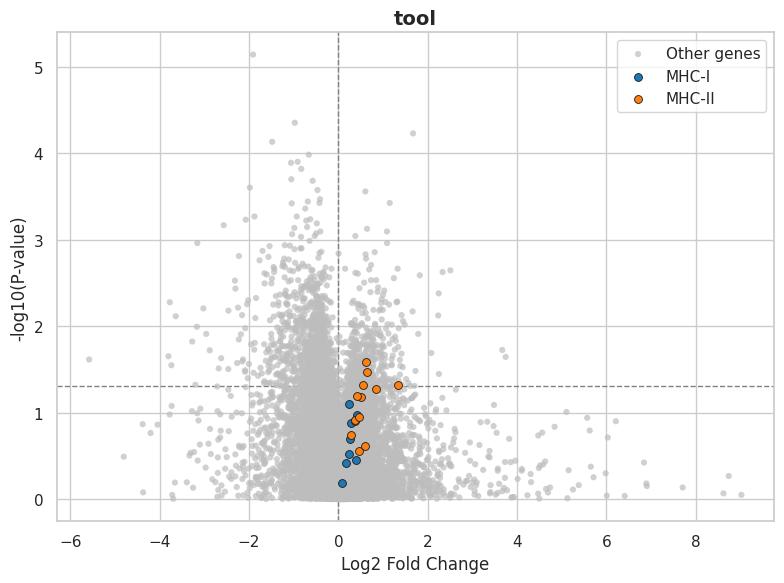

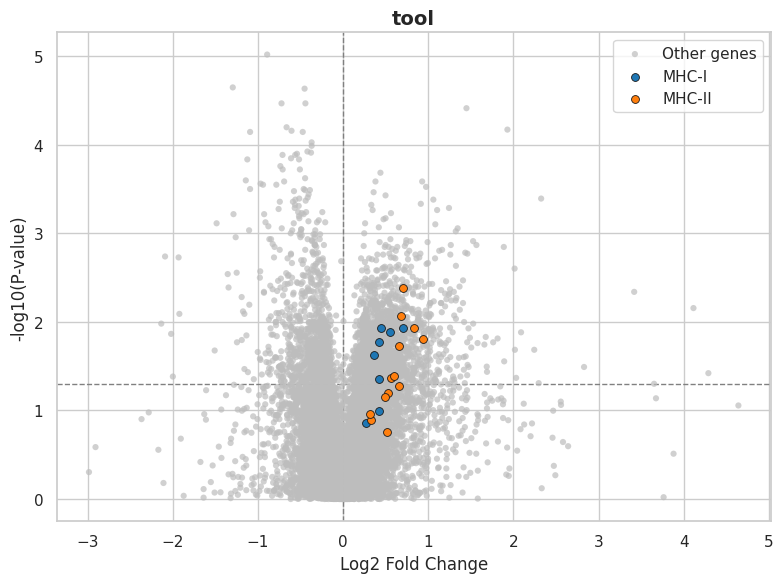

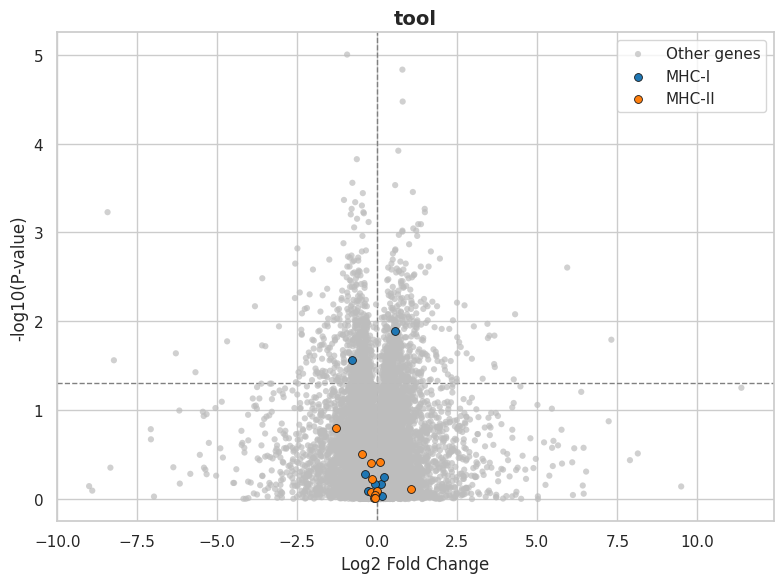

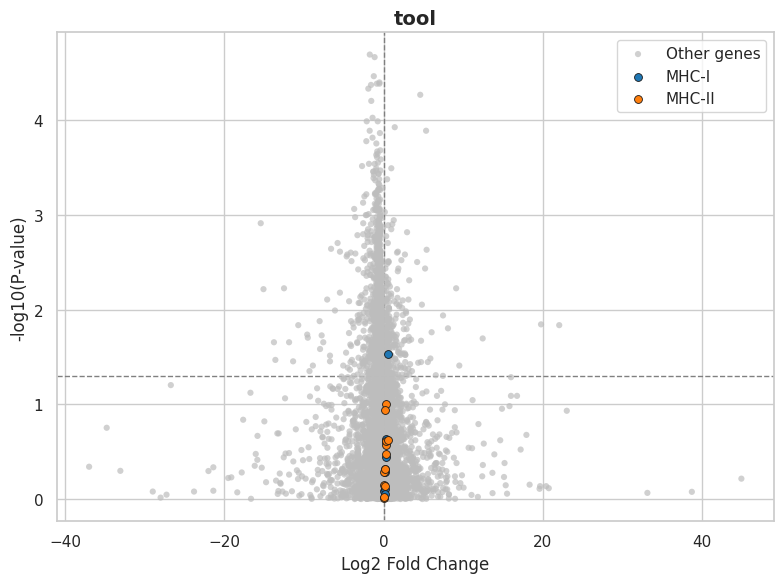

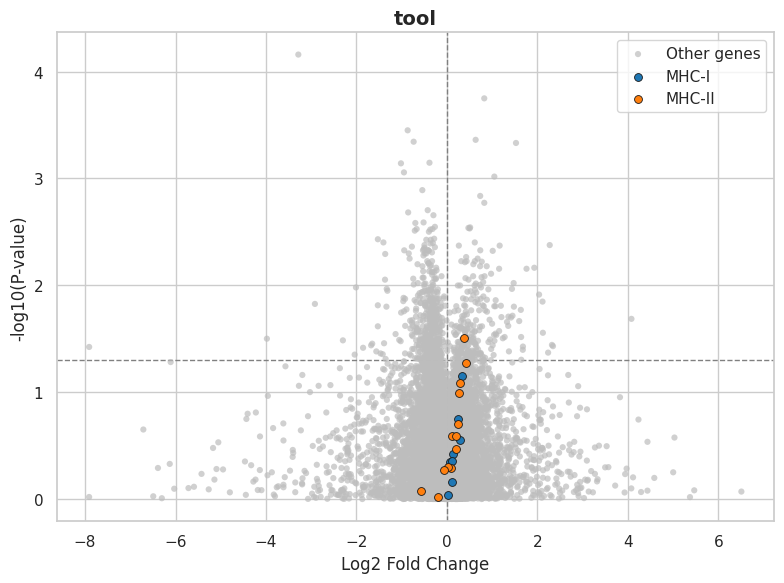

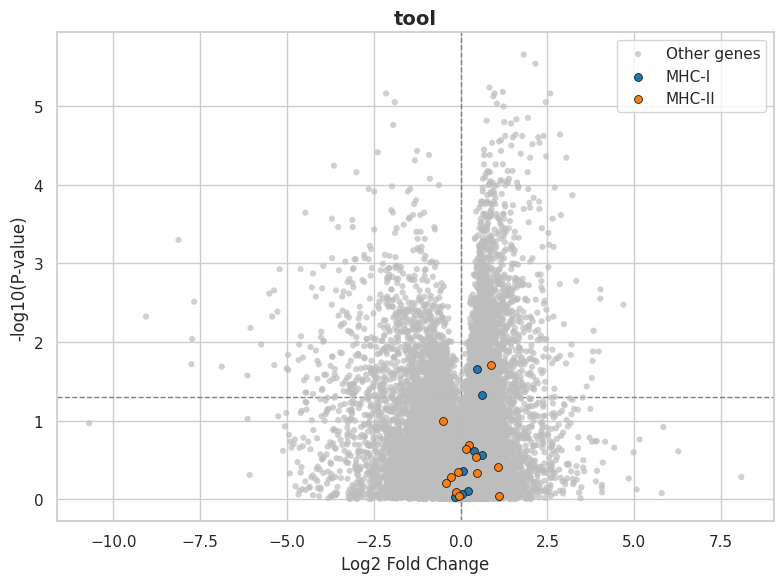

In [46]:
for tool, degs_result in degs_results.items():
    mhc1 = ['HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'HLA-F', 'TAP1', 'TAP2', 'B2M']
    mhc2 = ['HLA-DMA', 'HLA-DMB', 'HLA-DOA', 'HLA-DOB', 'HLA-DPA1', 'HLA-DPB1',
            'HLA-DQA1', 'HLA-DQA2', 'HLA-DQB1', 'HLA-DQB2', 'HLA-DRA', 'HLA-DRB1',
            'HLA-DRB5']
    fig = plot_volcano(degs_result, gene_col='Gene', log2fc_col='Log2FC', pval_col='P_value',
                       pval_thresh=0.05, mhc1=mhc1, mhc2=mhc2,
                       annotate=False, title = f"tool", savepath=f'DEGs/VolcanoPlot_{tool}.png')
    plt.show()